In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("data/processed/glp1_clean.csv")

print(f"Rows: {len(df)}")
print(df.head())

Rows: 220
          npi   last_name first_name            city state          specialty  \
0  1003002049  Srinivasan    Lakshmi         Fremont    CA      Endocrinology   
1  1003002049  Srinivasan    Lakshmi         Fremont    CA      Endocrinology   
2  1003004201   Philbrick    Natalie  Corpus Christi    TX  Internal Medicine   
3  1003004201   Philbrick    Natalie  Corpus Christi    TX  Internal Medicine   
4  1003004201   Philbrick    Natalie  Corpus Christi    TX  Internal Medicine   

  brand_name generic_name  total_claims  total_cost  total_patients  
0    Ozempic  semaglutide            70   133545.13            18.0  
1  Trulicity  dulaglutide            15    32458.42             0.0  
2    Ozempic  semaglutide            66    70837.96            14.0  
3   Rybelsus  semaglutide            16    16173.58             0.0  
4  Trulicity  dulaglutide            44    59138.23             0.0  


In [15]:
# Group by state and add up all prescriptions
state_claims = df.groupby('state')['total_claims'].sum().reset_index()

# Sort from highest to lowest
state_claims = state_claims.sort_values('total_claims', ascending=False)

# Keep top 15 states only
state_claims = state_claims.head(15)

print(state_claims)

   state  total_claims
0     AZ          2505
3     IL          1930
11    SC          1130
1     CA           805
4     KY           745
12    TX           630
6     MD           590
7     NC           385
14    WV           255
8     NY           240
13    VA           225
10    PA           185
5     MA           120
9     OH            70
2     IA            60


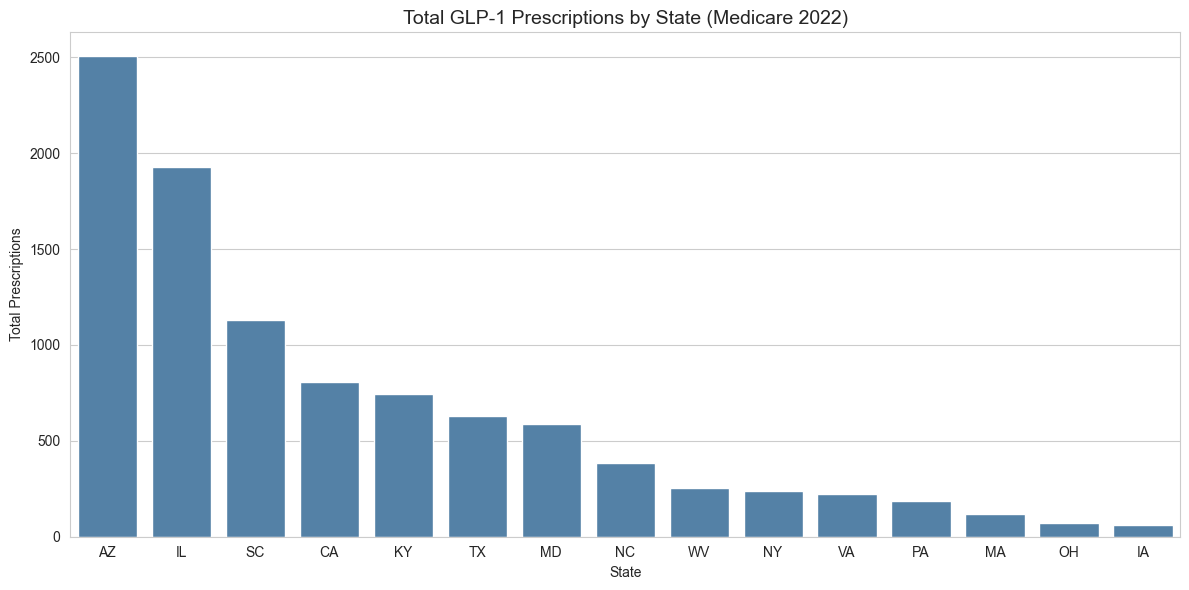

In [16]:
os.makedirs('outputs', exist_ok=True)

sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

sns.barplot(
    data=state_claims,
    x='state',
    y='total_claims',
    color='steelblue'
)

plt.title('Total GLP-1 Prescriptions by State (Medicare 2022)', fontsize=14)
plt.xlabel('State')
plt.ylabel('Total Prescriptions')

plt.tight_layout()
plt.savefig('outputs/glp1_by_state.png', dpi=150)
plt.show()

In [17]:
# Group by drug and add up all prescriptions
drug_claims = df.groupby('generic_name')['total_claims'].sum().reset_index()
drug_claims = drug_claims.sort_values('total_claims', ascending=False)

print(drug_claims)

  generic_name  total_claims
2  semaglutide          5450
0  dulaglutide          3700
1  liraglutide           615
3  tirzepatide           110


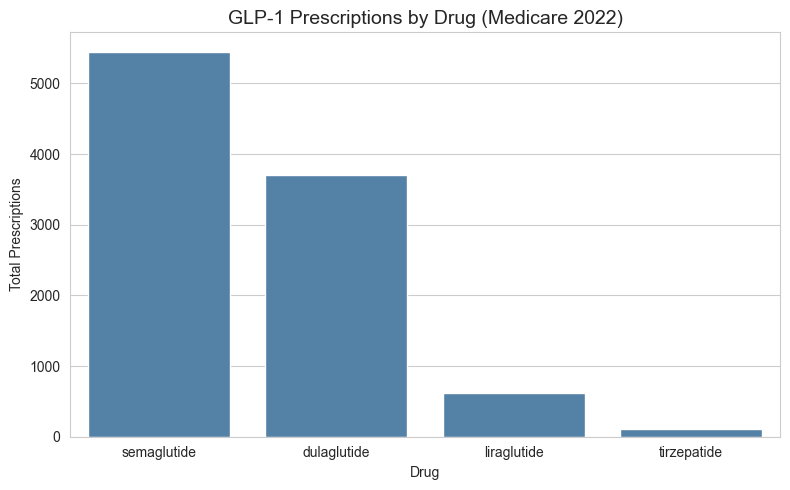

In [18]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=drug_claims,
    x='generic_name',
    y='total_claims',
    color='steelblue'
)

plt.title('GLP-1 Prescriptions by Drug (Medicare 2022)', fontsize=14)
plt.xlabel('Drug')
plt.ylabel('Total Prescriptions')
plt.tight_layout()
plt.savefig('outputs/glp1_by_drug.png', dpi=150)
plt.show()

In [19]:
# Group by specialty and add up prescriptions
specialty_claims = df.groupby('specialty')['total_claims'].sum().reset_index()
specialty_claims = specialty_claims.sort_values('total_claims', ascending=False)
specialty_claims = specialty_claims.head(10)

print(specialty_claims)

             specialty  total_claims
2      Family Practice          3655
1        Endocrinology          2255
5  Physician Assistant          1590
3    Internal Medicine          1445
4   Nurse Practitioner           830
0           Cardiology           100


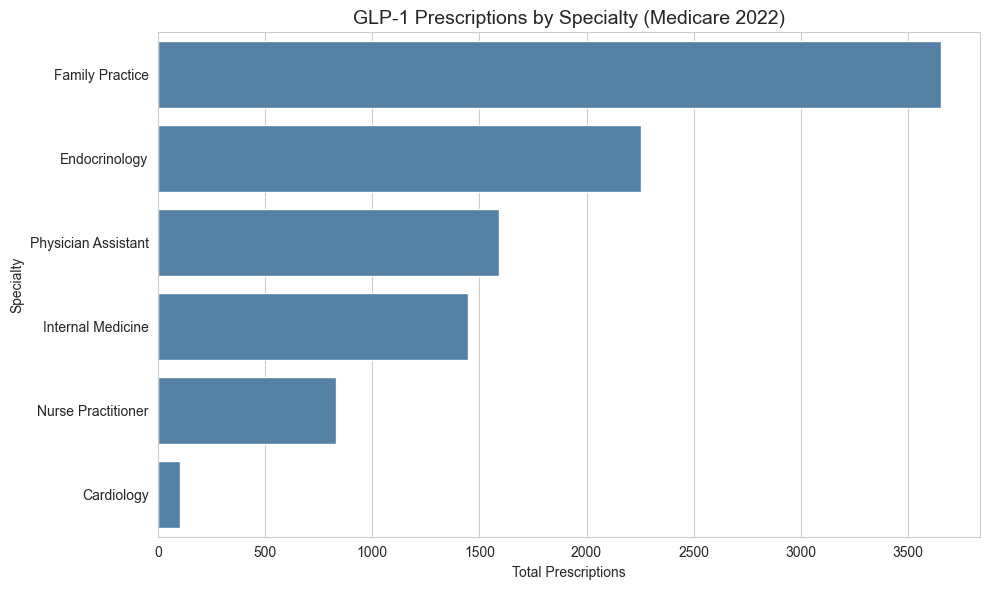

In [20]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=specialty_claims,
    x='total_claims',
    y='specialty',
    color='steelblue'
)

plt.title('GLP-1 Prescriptions by Specialty (Medicare 2022)', fontsize=14)
plt.xlabel('Total Prescriptions')
plt.ylabel('Specialty')
plt.tight_layout()
plt.savefig('outputs/glp1_by_specialty.png', dpi=150)
plt.show()